In [1]:
import pylbsr.notebooks
import pylbsr.misc

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from dotmap import DotMap
from tqdm import tqdm

import parnet
from parnet_additional_utils import GzListDataset, ParnetModelName, load_parnet_model
from parnet.layers import LinearProjectionHead

/mnt/storage1/workspace/lhofer/parnet--globalclip-head/.pixi/envs/parnet-dev-cu11/lib/python3.10/site-packages/gin/config.py:615: FutureWarning: `NLLLoss2d` has been deprecated. Please use `NLLLoss` instead as a drop-in replacement and see https://pytorch.org/docs/main/nn.html#torch.nn.NLLLoss for more details.
  decorated_class = decorating_meta(cls.__name__, (cls,), overrides)
Seed set to 42
/mnt/storage1/workspace/lhofer/parnet--globalclip-head/.pixi/envs/parnet-dev-cu11/lib/python3.10/site-packages/parnet/constants.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could b

In [2]:
_notebook_name = "03_integrated_gradients.ipynb"
_notebook_path = f"notebooks/globalclip-head/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)
logger = pylbsr.misc.init_logger(_notebook_name)
PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

[16:21:49] INFO - Project directory: /mnt/storage1/workspace/lhofer/parnet--globalclip-head


In [3]:
# ── GPU setup ──────────────────────────────────────────────────────────────────
pylbsr.misc.set_seed(42)

params_gpu_index = 0
device = torch.device(f"cuda:{params_gpu_index}")
torch.cuda.set_device(params_gpu_index)

if torch.cuda.is_available():
    logger.info(f"Using GPU: {torch.cuda.get_device_name(device)}")
else:
    logger.warning("No GPU available, using CPU instead.")

[16:21:52] INFO - Using GPU: NVIDIA RTX A4000


Seed set to 42
⏱ 0.13 s (00:00:00)


In [4]:
# ── Parameters ─────────────────────────────────────────────────────────────────
# Run to load the model from
EVAL_RUN = "parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl"

# Integrated Gradients settings
params_n_steps: int = 50        # number of interpolation steps
params_n_sequences: int = 10   # number of test sequences to compute IG on

# Data
params_seq_length: int = 600
params_num_tasks: int = 1

⏱ 0.00 s (00:00:00)


In [5]:
# ── Filepaths ──────────────────────────────────────────────────────────────────
_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())

FILEPATHS = DotMap()
FILEPATHS["data"] = Path(_fp_cfg["global_clip"]["data_lysate_noNHS_filtered"])
FILEPATHS["pretrained_model"] = Path(_fp_cfg["models"][ParnetModelName.PARNET_7M_0_0.value])
FILEPATHS["run_dir"] = PROJECT_DIR / "results" / "globalclip-head" / "training" / EVAL_RUN
FILEPATHS["output_dir"] = FILEPATHS["run_dir"] / "integrated_gradients"
FILEPATHS["figures_dir"] = PROJECT_DIR / "results" / "globalclip-head" / "figures"

FILEPATHS["output_dir"].mkdir(parents=True, exist_ok=True)
FILEPATHS["figures_dir"].mkdir(parents=True, exist_ok=True)

logger.info(f"Run dir:    {FILEPATHS.run_dir}")
logger.info(f"Output dir: {FILEPATHS.output_dir}")

[16:23:08] INFO - Run dir:    /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl
[16:23:08] INFO - Output dir: /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl/integrated_gradients


⏱ 0.01 s (00:00:00)


In [6]:
# ── Load test dataset ──────────────────────────────────────────────────────────
test_ds = GzListDataset(
    FILEPATHS.data, split="test",
    length=params_seq_length, total_key="globalCLIP", control_key="control",
    shuffle=False, mmap=True,
)

n_sequences = len(test_ds) if params_n_sequences is None else params_n_sequences
logger.info(f"Test size: {len(test_ds)} — computing IG on {n_sequences} sequences")

Loading (mmap) globalclip_lysate_noNHS.minreads3.maxsignal1000.pt split='test'... 

[16:23:19] INFO - Test size: 4896 — computing IG on 10 sequences


loaded 4896 samples.
⏱ 7.48 s (00:00:07)


In [7]:
# ── Load model ─────────────────────────────────────────────────────────────────
class GlobalCLIPHead(torch.nn.Module):
    def __init__(self, num_tasks=1):
        super().__init__()
        self.projection = LinearProjectionHead(num_tasks)

    def forward(self, inputs, **kwargs):
        logit = self.projection(inputs)
        logprob = logit - torch.logsumexp(logit, dim=-1, keepdim=True)
        return {
            'total': logprob,
            'mix_coeff': torch.ones(inputs.shape[0], 1, device=inputs.device),
        }

model = load_parnet_model(
    ParnetModelName.PARNET_7M_0_0,
    FILEPATHS["pretrained_model"],
    dtype=torch.float32,
    device=device,
)

model.head = GlobalCLIPHead(num_tasks=params_num_tasks).to(device)

# initialize lazy parameters
with torch.no_grad():
    _dummy = torch.zeros(1, 512, params_seq_length, device=device)
    model.head(_dummy)

# load fine-tuned weights
_checkpoint = torch.load(FILEPATHS["run_dir"] / "model.statedict.pt", map_location=device)
model.load_state_dict(_checkpoint["state_dict"])
model.eval()
logger.info(f"Model loaded from: {FILEPATHS.run_dir / 'model.statedict.pt'}")

/tmp/ipykernel_9363/3268290764.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _checkpoint = torch.load(FILEPATHS["run_dir"] / "model.statedict.pt", map_location=device

⏱ 0.55 s (00:00:00)


In [8]:
# ── Integrated Gradients implementation ────────────────────────────────────────
def integrated_gradients(model, sequence, n_steps=50):
    """
    Compute Integrated Gradients for a single sequence.
    
    Args:
        model: fine-tuned GlobalCLIP model
        sequence: (1, 4, 600) one-hot encoded sequence tensor
        n_steps: number of interpolation steps between baseline and input
    
    Returns:
        attributions: (4, 600) attribution scores
    """
    baseline = torch.zeros_like(sequence)  # all-zeros baseline (no information)
    
    # interpolate between baseline and input: (n_steps, 1, 4, 600)
    alphas = torch.linspace(0, 1, n_steps, device=sequence.device)
    interpolated = torch.stack([
        baseline + alpha * (sequence - baseline)
        for alpha in alphas
    ])  # (n_steps, 1, 4, 600)
    interpolated = interpolated.squeeze(1)  # (n_steps, 4, 600)
    interpolated.requires_grad_(True)
    
    # forward pass on all interpolated sequences at once
    output = model(sequence=interpolated)
    target = output['total'].sum()  # scalar
    
    # compute gradients
    target.backward()
    grads = interpolated.grad  # (n_steps, 4, 600)
    
    # average gradients and scale by (input - baseline)
    avg_grads = grads.mean(0)  # (4, 600)
    attributions = avg_grads * (sequence.squeeze(0) - baseline.squeeze(0))
    
    return attributions.detach().cpu()

⏱ 0.00 s (00:00:00)


In [12]:
# ── Compute IG for all test sequences ──────────────────────────────────────────
all_attributions = []
all_sequences = []

model.eval()
for i in tqdm(range(n_sequences)):
    sample = test_ds[i]
    
    # get one-hot encoded sequence (4, 600)
    sequence = sample["inputs"]["sequence"].unsqueeze(0).to(device)  # (1, 4, 600)
    
    # compute IG
    attrs = integrated_gradients(model, sequence, n_steps=params_n_steps)  # (4, 600)
    
    all_attributions.append(attrs.numpy())
    all_sequences.append(sample["inputs"]["sequence"].numpy())

all_attributions = np.stack(all_attributions)  # (n_sequences, 4, 600)
all_sequences = np.stack(all_sequences)         # (n_sequences, 4, 600)

logger.info(f"Computed IG for {n_sequences} sequences")
logger.info(f"Attribution maps shape: {all_attributions.shape}")

100%|██████████| 10/10 [00:11<00:00,  1.16s/it]
[16:27:14] INFO - Computed IG for 10 sequences
[16:27:14] INFO - Attribution maps shape: (10, 4, 600)


⏱ 11.58 s (00:00:11)


In [13]:
# ── Save attribution maps ──────────────────────────────────────────────────────
np.save(FILEPATHS["output_dir"] / "attributions.npy", all_attributions)
np.save(FILEPATHS["output_dir"] / "sequences.npy", all_sequences)
logger.info(f"Saved attribution maps → {FILEPATHS.output_dir}")

[16:28:42] INFO - Saved attribution maps → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.filtered.noctrl/integrated_gradients


⏱ 0.07 s (00:00:00)


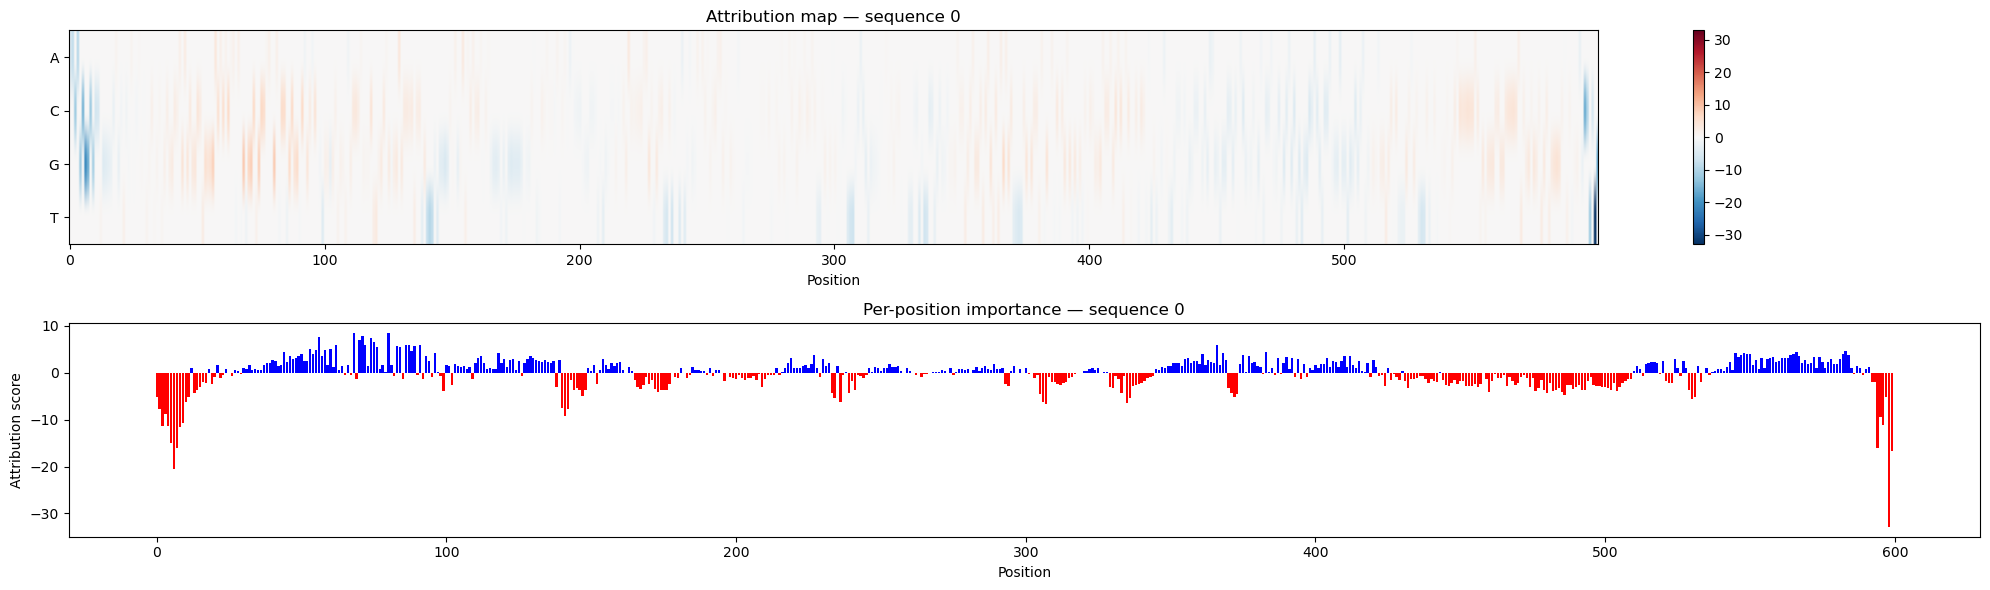

⏱ 1.95 s (00:00:01)


In [14]:
# ── Visualize single attribution map ───────────────────────────────────────────
NUCLEOTIDES = ["A", "C", "G", "T"]
SEQ_IDX = 0  # which sequence to visualize

fig, axes = plt.subplots(2, 1, figsize=(20, 6))

# ── Attribution map (4 nucleotides x 600 positions) ───────────────────────────
im = axes[0].imshow(
    all_attributions[SEQ_IDX],
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.abs(all_attributions[SEQ_IDX]).max(),
    vmax=np.abs(all_attributions[SEQ_IDX]).max(),
)
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(NUCLEOTIDES)
axes[0].set_xlabel("Position")
axes[0].set_title(f"Attribution map — sequence {SEQ_IDX}")
plt.colorbar(im, ax=axes[0])

# ── Per-position importance (sum over nucleotides) ─────────────────────────────
importance = all_attributions[SEQ_IDX].sum(axis=0)  # (600,)
axes[1].bar(range(600), importance, color=["red" if v < 0 else "blue" for v in importance])
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Attribution score")
axes[1].set_title(f"Per-position importance — sequence {SEQ_IDX}")

plt.tight_layout()
plt.savefig(FILEPATHS["figures_dir"] / f"attribution_map_seq{SEQ_IDX}.png", dpi=150, bbox_inches="tight")
plt.show()

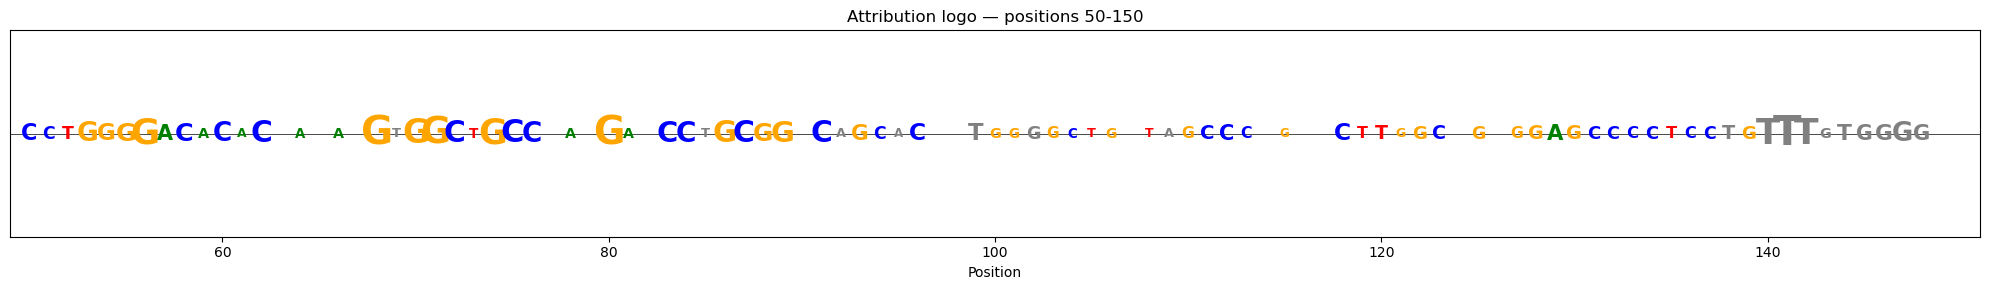

<Figure size 640x480 with 0 Axes>

⏱ 0.59 s (00:00:00)


In [17]:
def plot_attribution_logo(attributions, sequence, start=0, end=100, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 3))
    
    NUCLEOTIDES = ["A", "C", "G", "T"]
    COLORS = {"A": "green", "C": "blue", "G": "orange", "T": "red"}
    
    # normalize scores to make font sizes more visible
    max_score = np.abs(attributions[:, start:end]).max()
    
    for pos in range(start, end):
        for nuc_idx, nuc in enumerate(NUCLEOTIDES):
            if sequence[nuc_idx, pos] == 0:
                continue
            score = attributions[nuc_idx, pos]
            if abs(score) < 0.1 * max_score:  # skip bottom 10%
                continue
            fontsize = 6 + (abs(score) / max_score) * 24  # scale 6-30
            color = COLORS[nuc] if score > 0 else "gray"
            ax.text(
                pos, 0, nuc,
                fontsize=fontsize,
                color=color,
                ha="center", va="center",
                fontweight="bold",
            )
    
    ax.set_xlim(start - 1, end + 1)
    ax.set_ylim(-1, 1)
    ax.set_xlabel("Position")
    ax.set_title(f"Attribution logo — positions {start}-{end}")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_yticks([])
    return ax

fig, ax = plt.subplots(figsize=(20, 3))
plot_attribution_logo(all_attributions[SEQ_IDX], all_sequences[SEQ_IDX], start=50, end=150, ax=ax)
plt.tight_layout()
plt.show()
plt.savefig(FILEPATHS["figures_dir"] / f"attribution_logo_seq{SEQ_IDX}.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# ── Load RBP motifs ────────────────────────────────────────────────────────────
import pylbsr.bio.motifs as motifs_lib
from pylbsr.bio.motifs.motif import convert_matrix_type

MOTIFS_DIR = Path("/mnt/storage1/ml4rg26-shared/rbp_binding_motifs")
DATABASES = ["mCrossBase", "ATtRACT", "RBPmap_1.2", "oRNAment", "RBPDB"]

def load_motif_ppm(f):
    """Load a .transfac motif and convert to PPM for scoring."""
    with open(f) as fh:
        ms = motifs_lib.read_motifs_transfac(fh)
    if not ms:
        return None
    m = ms[0]
    
    # get matrix type from filename (e.g. K562.PCM.000.transfac)
    mt = f.stem.split(".")[1].upper()  # PCM, PPM, PWM
    m.matrix_type = mt
    
    try:
        if mt in ("PCM", "PPM"):
            m = convert_matrix_type(m, "PPM")
        else:
            return None  # skip PWM
    except Exception:
        return None
    return m

# load all motifs
all_motifs = {}  # {rbp_name: [ppm_array, ...]}
for db in DATABASES:
    preproc = MOTIFS_DIR / db / "preprocessed"
    if not preproc.exists():
        continue
    for rbp_dir in preproc.iterdir():
        if not rbp_dir.is_dir():
            continue
        rbp = rbp_dir.name
        for f in rbp_dir.glob("*.transfac"):
            m = load_motif_ppm(f)
            if m is None:
                continue
            if rbp not in all_motifs:
                all_motifs[rbp] = []
            all_motifs[rbp].append(m.matrix.to_numpy(dtype=float))

logger.info(f"Loaded motifs for {len(all_motifs)} RBPs")

[16:40:36] INFO - Loaded motifs for 430 RBPs


⏱ 55.03 s (00:00:55)


In [21]:
# ── Motif scanning against attribution maps ────────────────────────────────────
from scipy.stats import pearsonr

MIN_OVERLAP = 4  # minimum positions for valid alignment

def score_motif_attribution(attribution, motif_ppm, min_overlap=MIN_OVERLAP):
    """
    Slide a motif PPM across an attribution map and return the best PCC score.
    
    Args:
        attribution: (4, 600) attribution map
        motif_ppm: (L, 4) PPM matrix as numpy array
        min_overlap: minimum overlap positions
    
    Returns:
        best_score: float, best PCC across all positions
        best_pos: int, position of best match
    """
    L = motif_ppm.shape[0]
    seq_len = attribution.shape[1]
    
    best_score = -np.inf
    best_pos = 0
    
    for start in range(-L + min_overlap, seq_len - min_overlap + 1):
        # get overlapping region
        seq_start = max(0, start)
        seq_end = min(seq_len, start + L)
        mot_start = seq_start - start
        mot_end = mot_start + (seq_end - seq_start)
        
        if seq_end - seq_start < min_overlap:
            continue
        
        # attribution slice: (4, overlap) → flatten
        attr_slice = attribution[:, seq_start:seq_end].T.flatten()  # (overlap*4,)
        motif_slice = motif_ppm[mot_start:mot_end].flatten()         # (overlap*4,)
        
        if attr_slice.std() == 0 or motif_slice.std() == 0:
            continue
        
        score = pearsonr(attr_slice, motif_slice)[0]
        if score > best_score:
            best_score = score
            best_pos = seq_start
    
    return best_score, best_pos

⏱ 0.00 s (00:00:00)


In [22]:
# ── Scan all RBPs against attribution maps ─────────────────────────────────────
# For each RBP, take the best score across all its motifs and all sequences

rbp_scores = {}  # {rbp: mean best score across sequences}

for rbp, motif_list in tqdm(all_motifs.items(), desc="Scanning RBPs"):
    seq_best_scores = []
    
    for seq_idx in range(len(all_attributions)):
        attr = all_attributions[seq_idx]  # (4, 600)
        
        # take best score across all motifs for this RBP
        best_rbp_score = -np.inf
        for motif_ppm in motif_list:
            score, _ = score_motif_attribution(attr, motif_ppm)
            if score > best_rbp_score:
                best_rbp_score = score
        
        seq_best_scores.append(best_rbp_score)
    
    rbp_scores[rbp] = np.mean(seq_best_scores)

# sort by score
rbp_scores_sorted = dict(sorted(rbp_scores.items(), key=lambda x: x[1], reverse=True))
logger.info(f"Scanned {len(rbp_scores_sorted)} RBPs")

# print top 20
print("\nTop 20 RBPs by mean attribution match score:")
for rbp, score in list(rbp_scores_sorted.items())[:20]:
    print(f"  {rbp:20s}  {score:.4f}")

Scanning RBPs:  12%|█▏        | 51/430 [16:03<1:59:20, 18.89s/it]


KeyboardInterrupt: 

⏱ 963.92 s (00:16:03)
